In [14]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem import rdFingerprintGenerator
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

Only PAINS using tSNE

In [24]:
df = pd.read_csv("data/PAINS.smi", sep="\t")
print(len(df))
print(df.columns)

320
Index(['SMILES', 'Catalog ID', 'MW', 'MW (desalted)', 'ClogP', 'logS', 'HBD',
       'HBA', 'TPSA', 'RotBonds'],
      dtype='object')


In [16]:
# Generate Morgan fingerprints
mols = [Chem.MolFromSmiles(smi) for smi in df['SMILES']]
fmgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = np.array([fmgen.GetFingerprint(mol) for mol in mols])

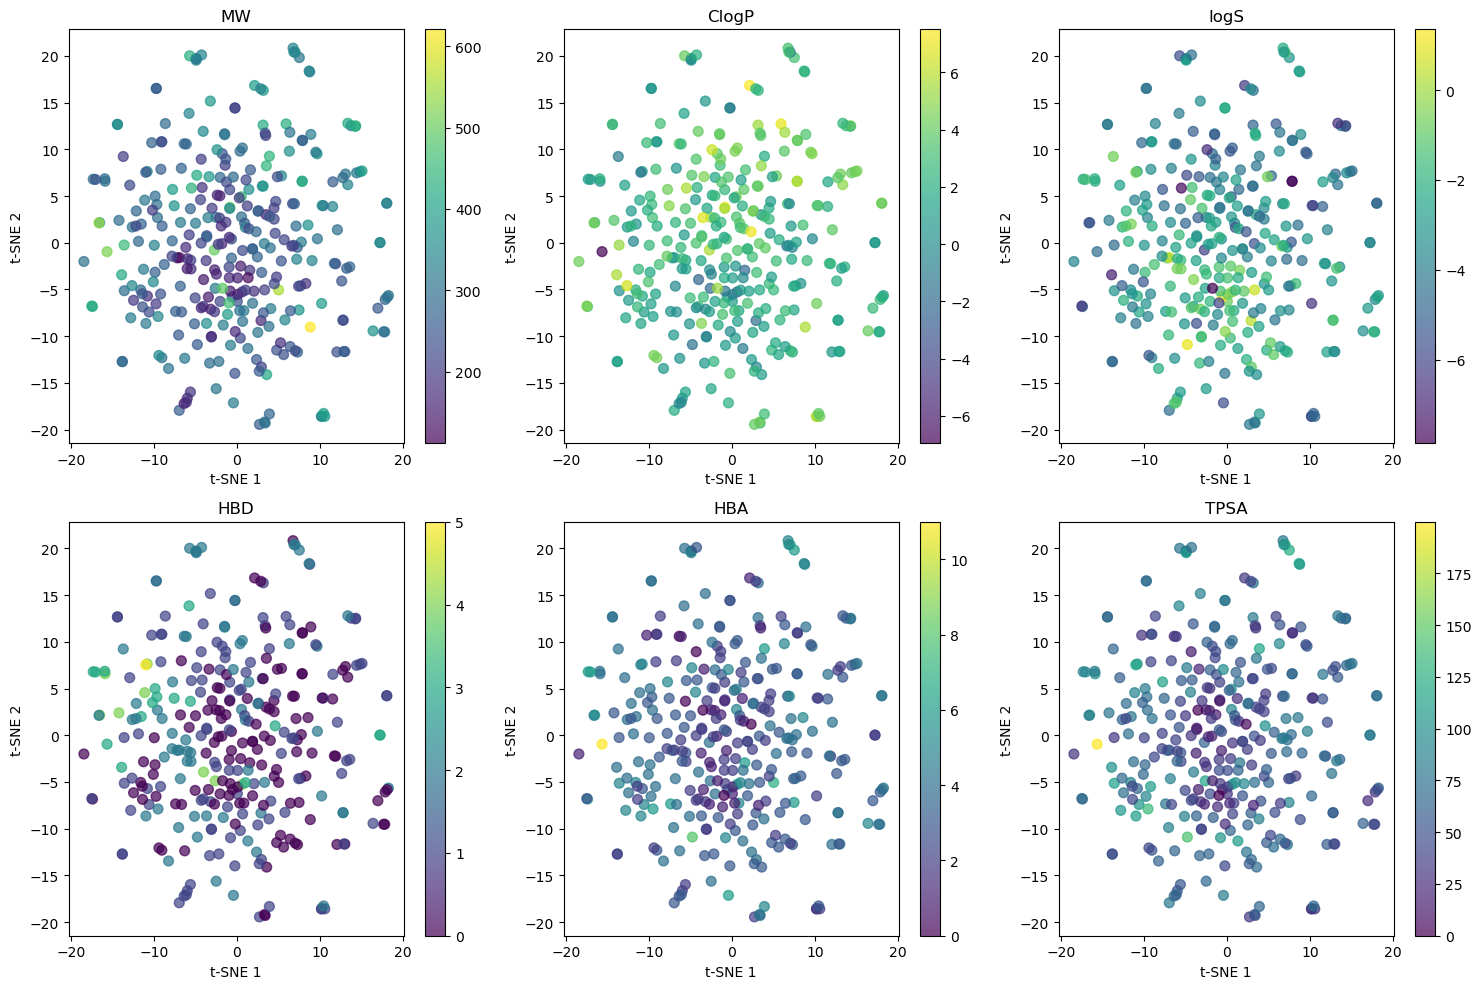

In [17]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(fps)-1))
coords = tsne.fit_transform(fps)

# Plot with different properties
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
properties = ['MW', 'ClogP', 'logS', 'HBD', 'HBA', 'TPSA']

for ax, prop in zip(axes.flat, properties):
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df[prop], cmap='viridis', s=50, alpha=0.7)
    ax.set_title(prop)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
#plt.savefig('tsne_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

Using the full 2Z65 data

In [48]:
df = pd.read_csv("data/2Z65_with_properties_2Z65binding.txt", sep=",")
print(len(df))
print(df.columns)
print(df["Label"].value_counts())

343
Index(['SMILES', 'MolWt', 'LogP', 'QED', 'SAS', 'TPSA', 'H_Acceptors',
       'H_Donors', 'Rotatable_Bonds', 'Affinity', 'CNNaffinity', 'Label'],
      dtype='object')
Label
0    325
1     18
Name: count, dtype: int64


In [26]:
# Generate Morgan fingerprints
mols = [Chem.MolFromSmiles(smi) for smi in df['SMILES']]
fmgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = np.array([fmgen.GetFingerprint(mol) for mol in mols])

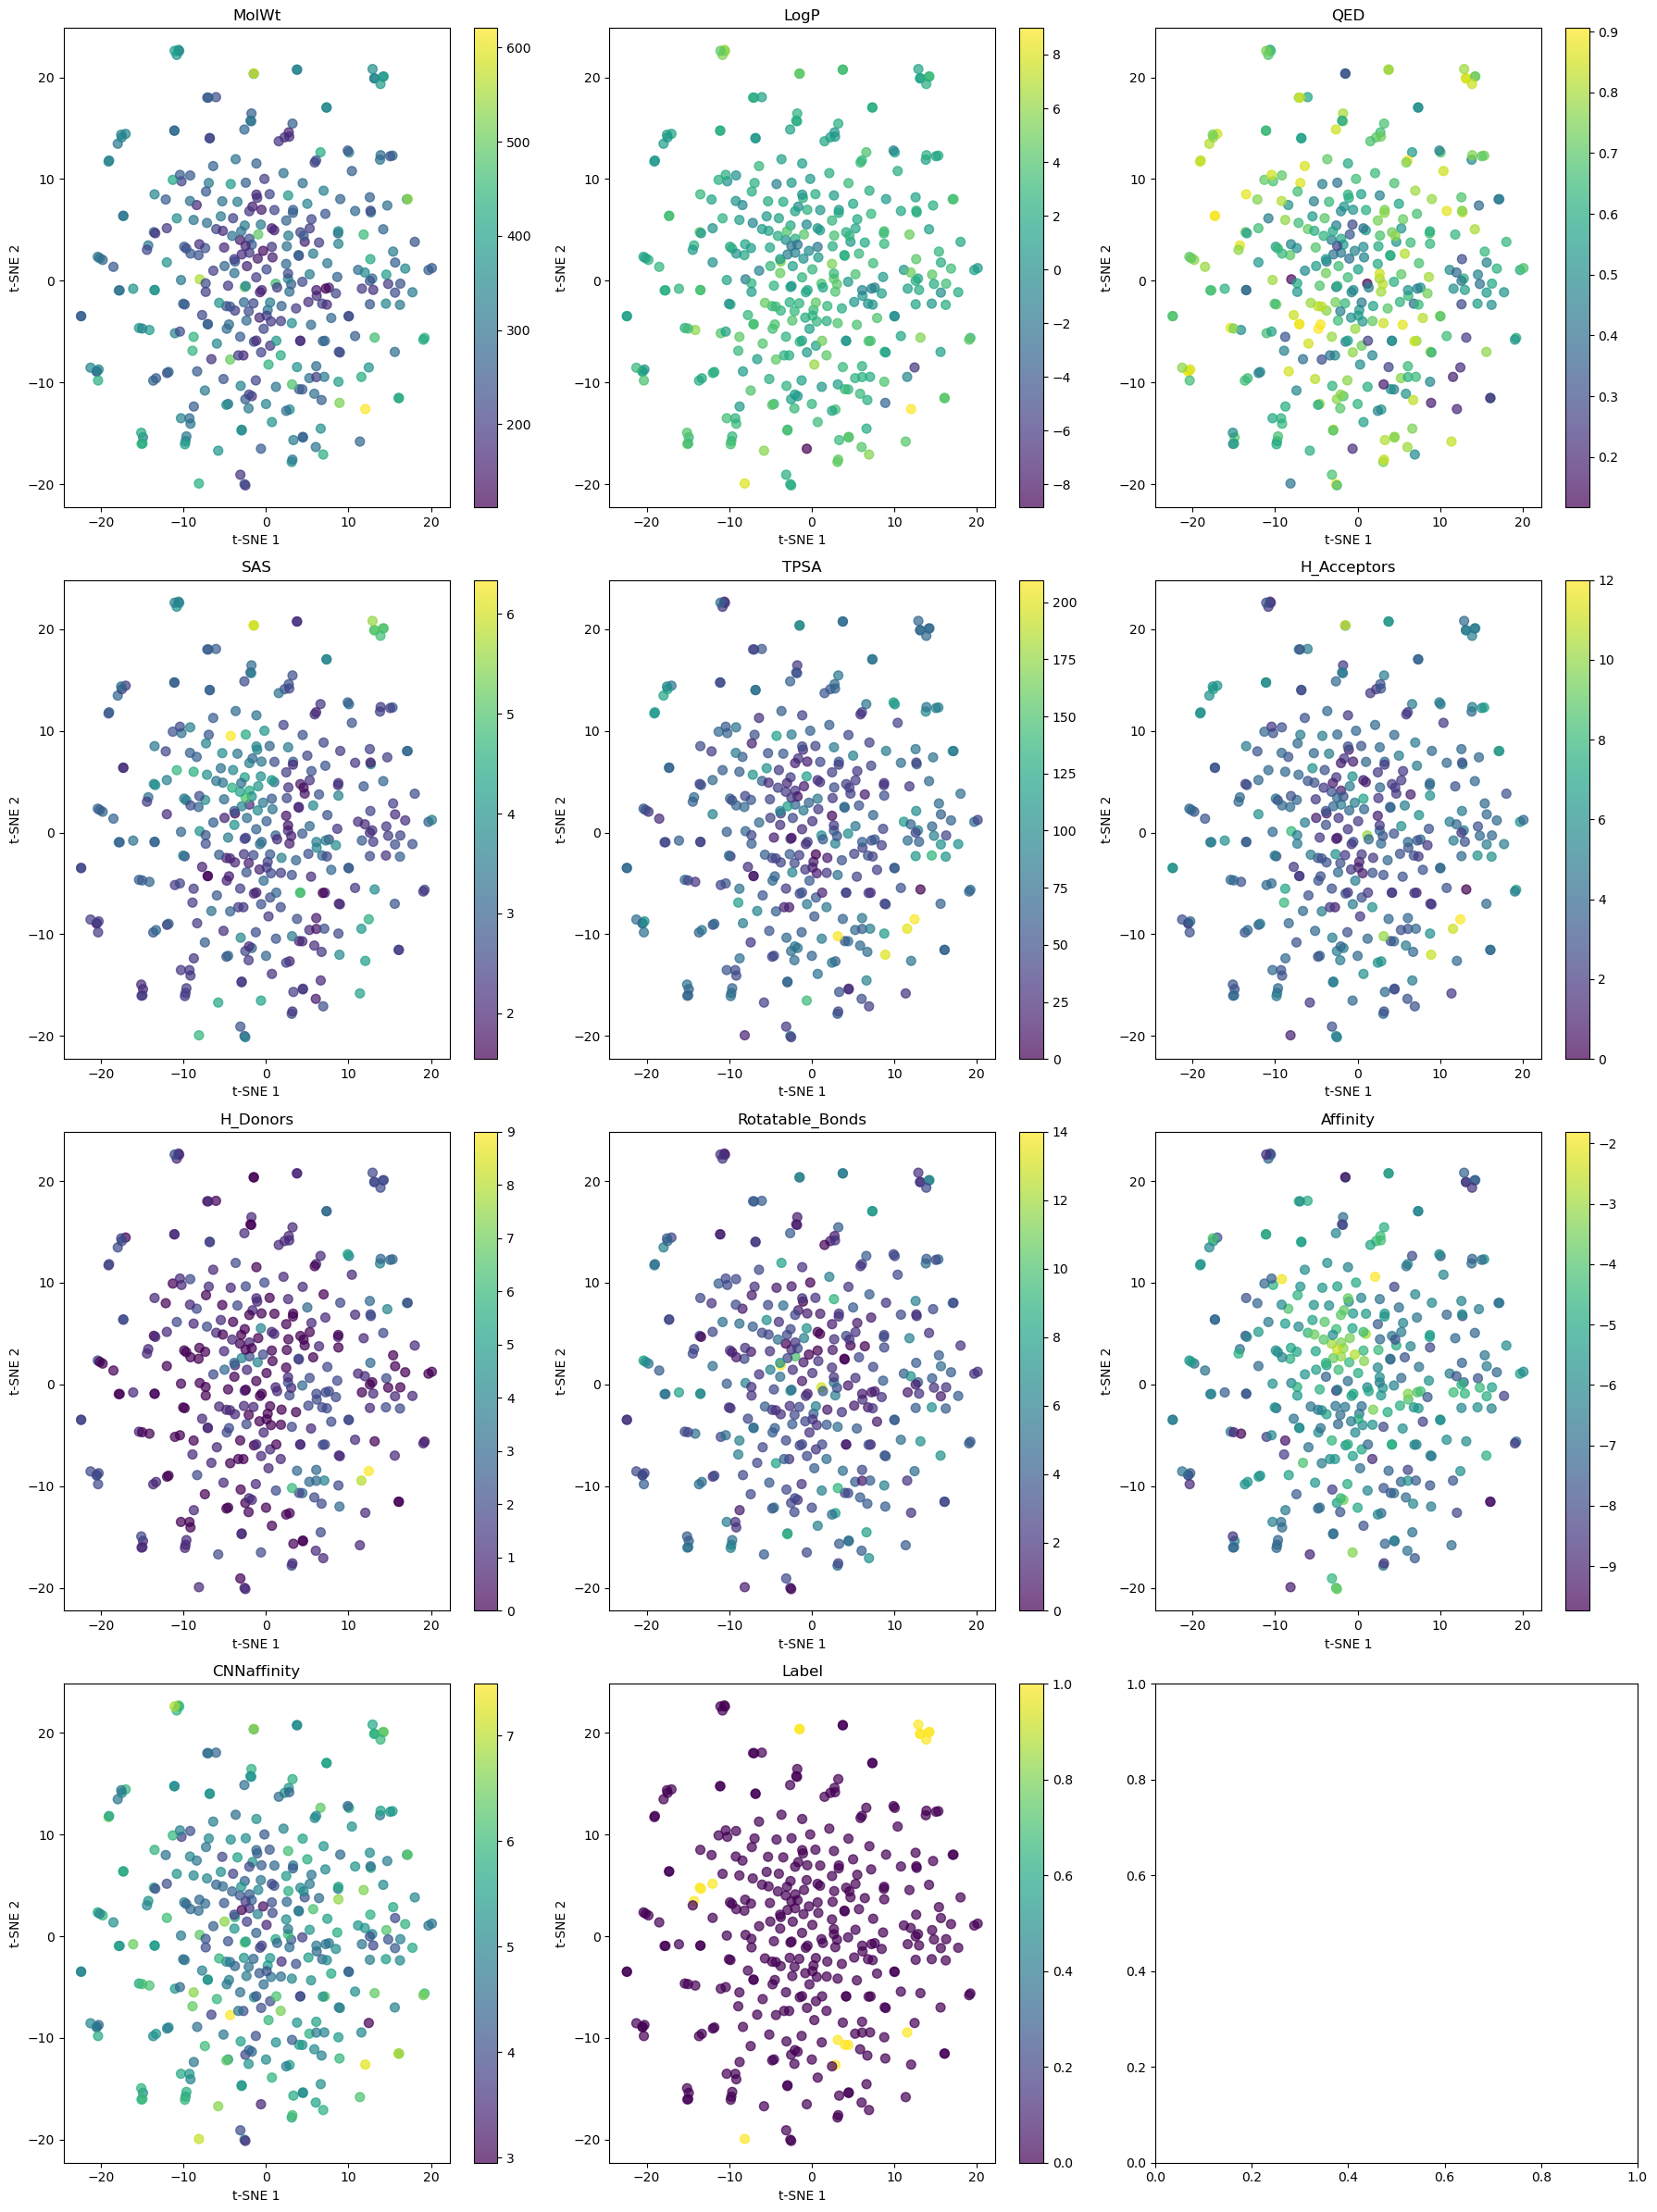

In [40]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(fps)-1))
coords = tsne.fit_transform(fps)

# Plot with different properties
fig, axes = plt.subplots(4, 3, figsize=(18, 24))
properties = ['MolWt', 'LogP', 'QED', 'SAS', 'TPSA', 'H_Acceptors', 'H_Donors', 'Rotatable_Bonds', 'Affinity', 'CNNaffinity', 'Label']

for ax, prop in zip(axes.flat, properties):
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df[prop], cmap='viridis', s=50, alpha=0.7)
    ax.set_title(prop)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
#plt.savefig('tsne_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

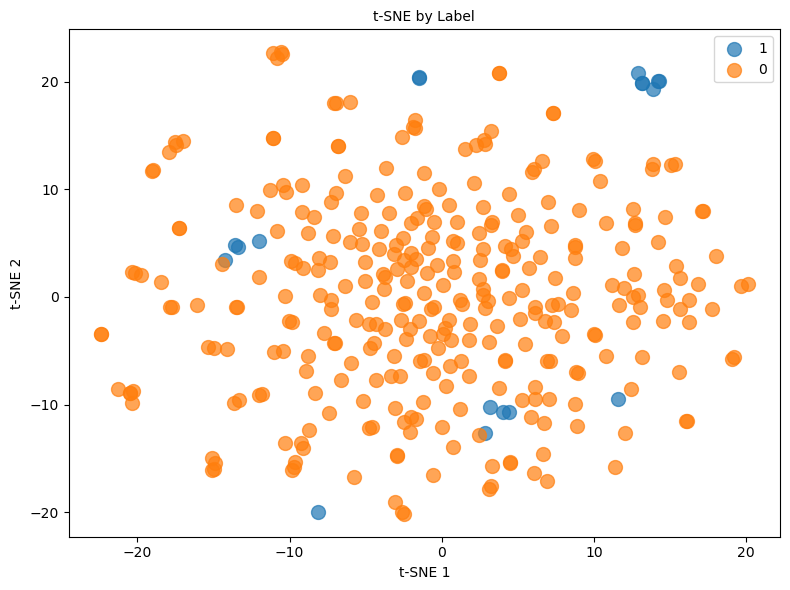

In [47]:
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(fps)-1))
coords = tsne.fit_transform(fps)

plt.figure(figsize=(8, 6))
unique_labels = df['Label'].unique()
for label in unique_labels:
    mask = df['Label'] == label
    plt.scatter(coords[mask, 0], coords[mask, 1], label=label, s=100, alpha=0.7)

plt.xlabel('t-SNE 1', fontsize=10)
plt.ylabel('t-SNE 2', fontsize=10)
plt.title('t-SNE by Label', fontsize=10)
plt.legend(fontsize=10, markerscale=1)
plt.tight_layout()
#plt.savefig('tsne_labels_large.png', dpi=300, bbox_inches='tight')
plt.show()

ML model of the full data (antagonist vs PAINS)

Cross-validation F1: 0.433 (+/- 0.108)
Fold F1 scores: [0.4        0.25       0.57142857 0.44444444 0.5       ]

Best fold: 2 with F1: 0.571

Feature Importance (mean +/- std):
           feature  importance       std
3              SAS    0.546435  0.065422
6         H_Donors    0.108042  0.069196
2              QED    0.088096  0.076498
9      CNNaffinity    0.083245  0.061213
4             TPSA    0.055203  0.080067
5      H_Acceptors    0.042588  0.054179
0            MolWt    0.039512  0.079025
7  Rotatable_Bonds    0.021400  0.037231
1             LogP    0.010179  0.020358
8         Affinity    0.005301  0.010601


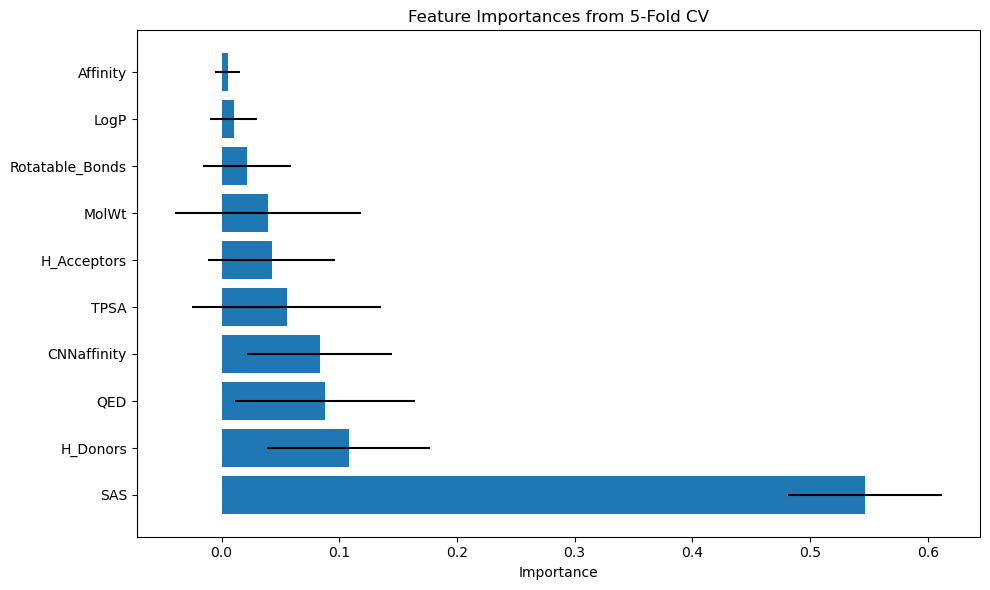

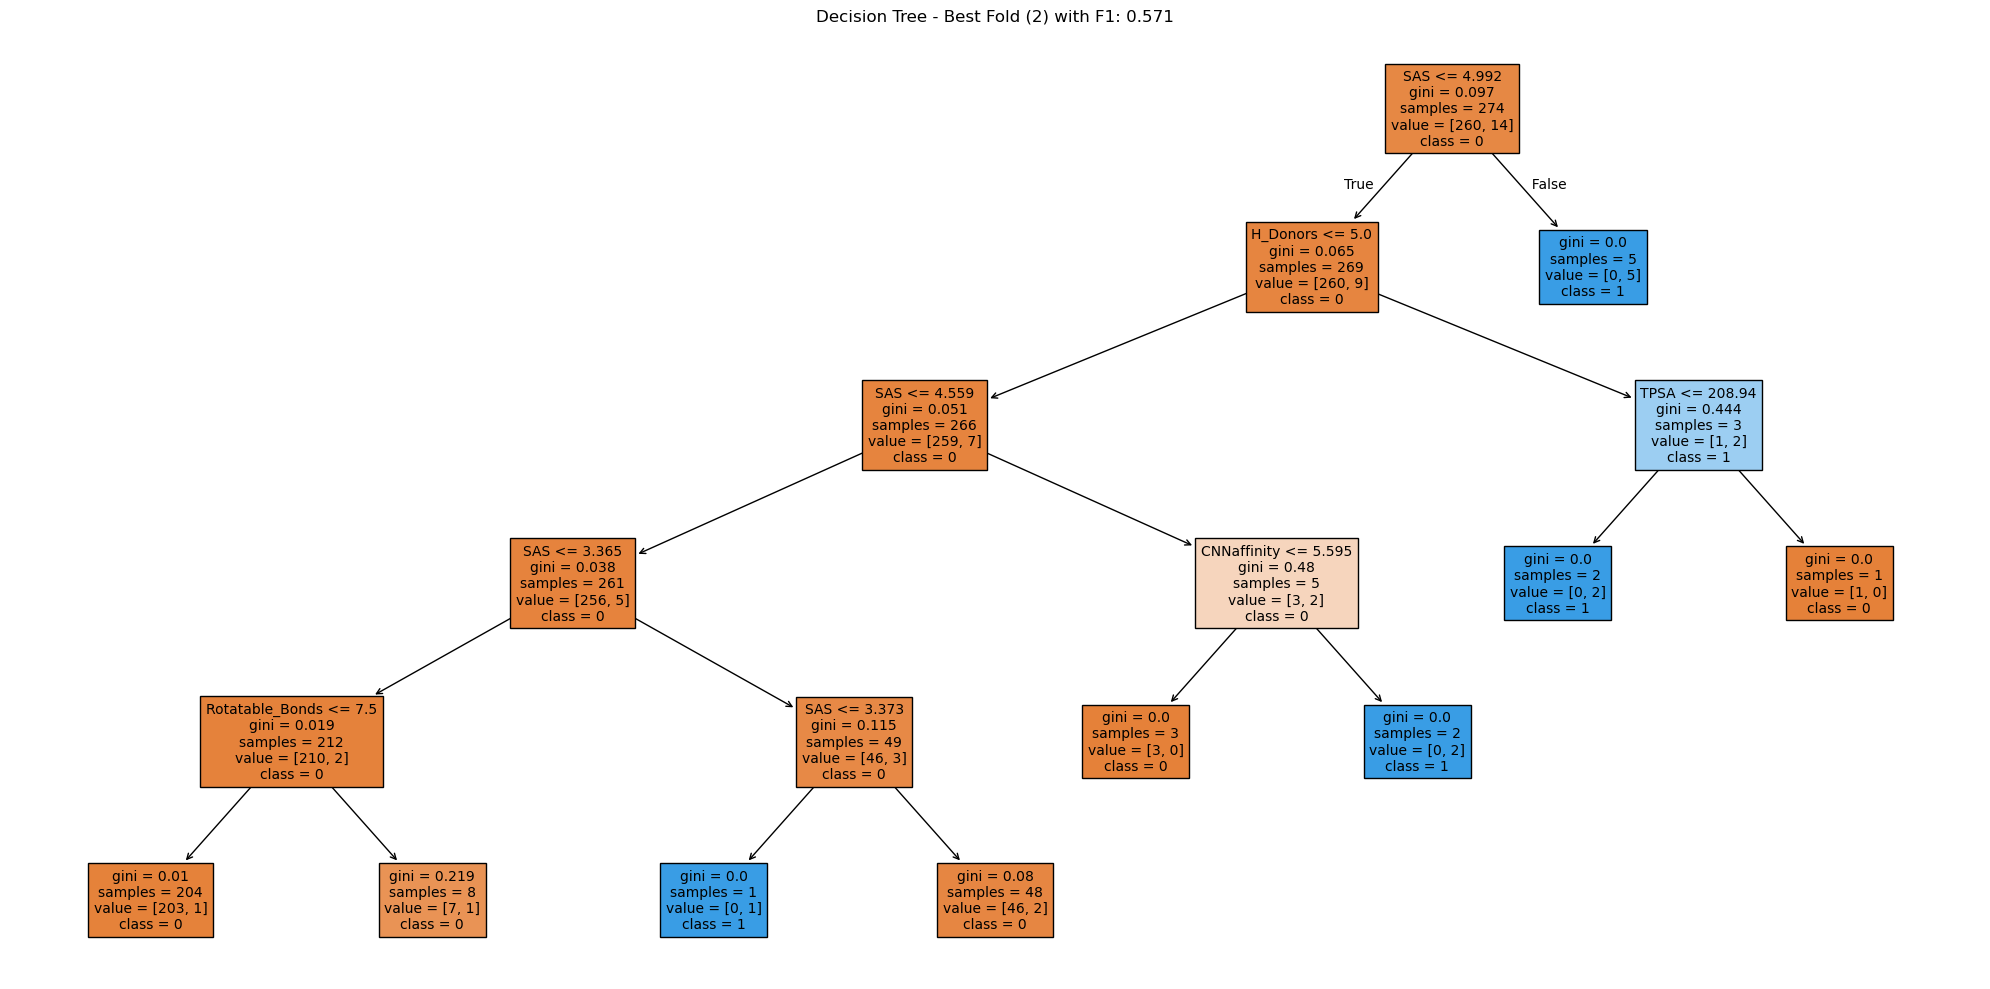

In [53]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Read data
df = pd.read_csv("data/2Z65_with_properties_2Z65binding.txt")

# Select features (bulk properties)
features = ['MolWt', 'LogP', 'QED', 'SAS', 'TPSA', 'H_Acceptors', 'H_Donors', 'Rotatable_Bonds', 'Affinity', 'CNNaffinity']
X = df[features]
y = df['Label']

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Determine scoring strategy
n_classes = len(y.unique())
scoring = 'f1' if n_classes == 2 else 'f1_weighted'

# Cross-validation with F1
cv_scores = cross_val_score(dt, X, y, cv=cv, scoring=scoring)
print(f"Cross-validation F1: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print(f"Fold F1 scores: {cv_scores}")

# Feature importances and find best fold
feature_importances = []
fold_scores = []
best_fold_idx = -1
best_f1 = -1
best_model = None
average = 'binary' if n_classes == 2 else 'weighted'

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    dt_fold = DecisionTreeClassifier(max_depth=5, random_state=42)
    dt_fold.fit(X_train, y_train)
    
    y_pred = dt_fold.predict(X_test)
    f1 = f1_score(y_test, y_pred, average=average)
    
    feature_importances.append(dt_fold.feature_importances_)
    fold_scores.append(f1)
    
    if f1 > best_f1:
        best_f1 = f1
        best_fold_idx = fold_idx
        best_model = dt_fold

print(f"\nBest fold: {best_fold_idx} with F1: {best_f1:.3f}")

# Average feature importances
avg_importance = np.mean(feature_importances, axis=0)
std_importance = np.std(feature_importances, axis=0)

importance_df = pd.DataFrame({
    'feature': features,
    'importance': avg_importance,
    'std': std_importance
}).sort_values('importance', ascending=False)

print("\nFeature Importance (mean +/- std):")
print(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], xerr=importance_df['std'])
plt.xlabel('Importance')
plt.title('Feature Importances from 5-Fold CV')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualize best fold tree
plt.figure(figsize=(20, 10))
plot_tree(best_model, feature_names=features, class_names=[str(c) for c in best_model.classes_], filled=True, fontsize=10)
plt.title(f'Decision Tree - Best Fold ({best_fold_idx}) with F1: {best_f1:.3f}')
plt.tight_layout()
plt.savefig('decision_tree_best_fold.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
import pandas as pd
df = pd.read_csv("results/GenMolMF/2Z65/gpt-4o/241025_1259/all.csv")
df.head(5)

,SMILES,MolWt,LogP,QED,SAS,TPSA,H_Acceptors,H_Donors,Rotatable_Bonds,Affinity,CNNaffinity,Label
0,CC(C)OC1=CC=CC=C1C2CCCCC2,218.340,4.52150,0.724361,1.784201,9.23,1,0,3,-6.75,5.011,-1
1,CC1=C(C=CC=C1)C(=O)N2CCC(CC2)N3CCOCC3,288.391,1.93182,0.833469,1.945835,32.78,3,0,2,-6.51,5.166,-1
2,CC1=CC=C(C=C1)C2=CC=CC=C2C(=O)O,212.248,3.36022,0.828281,1.365915,37.30,1,1,2,-6.58,4.467,-1
3,CC(C)C1=CC=C(C=C1)C(=O)OCC2=CC=CC=C2,254.329,4.16700,0.765449,1.436269,26.30,2,0,4,-7.02,5.150,-1
4,C1CCC(CC1)N2C=C(C=N2)C3=CC=CC=C3,226.323,4.05530,0.754845,1.928475,17.82,2,0,2,-6.75,4.798,-1


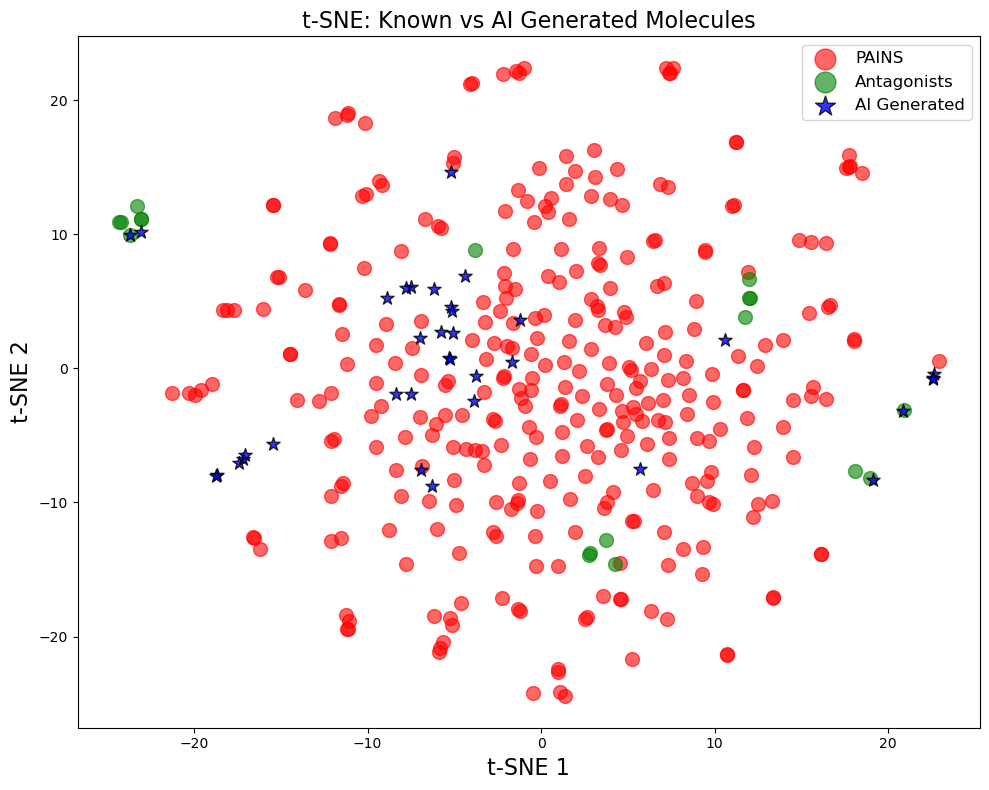

In [11]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Read known data (antagonists + PAINS)
df_known = pd.read_csv("data/2Z65_with_properties_2Z65binding.txt")
df_known['Source'] = 'Known'

# Read AI generated molecules
df_gen = pd.read_csv("results/GenMolMF/2Z65/gpt-4o/241025_1259/all.csv")
df_gen['Source'] = 'AI_Generated'

# Combine datasets
df_combined = pd.concat([df_known, df_gen], ignore_index=True)

# Generate Morgan fingerprints for all molecules
mols = [Chem.MolFromSmiles(smi) for smi in df_combined['SMILES']]
fmgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = np.array([fmgen.GetFingerprint(mol) for mol in mols])

# t-SNE on combined dataset
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(fps)-1))
coords = tsne.fit_transform(fps)

# Split coordinates back
n_known = len(df_known)
coords_known = coords[:n_known]
coords_gen = coords[n_known:]

# Plot
plt.figure(figsize=(10, 8))

mask_pains = df_known['Label'] == 0
plt.scatter(coords_known[mask_pains, 0], coords_known[mask_pains, 1], 
            label='PAINS', s=100, alpha=0.6, color='red')

mask_antagonists = df_known['Label'] == 1
plt.scatter(coords_known[mask_antagonists, 0], coords_known[mask_antagonists, 1], 
            label='Antagonists', s=100, alpha=0.6, color='green')

# Plot AI generated molecules
plt.scatter(coords_gen[:, 0], coords_gen[:, 1], 
            label='AI Generated', s=100, alpha=0.8, marker='*', edgecolors='black', linewidths=1, color='blue')

plt.xlabel('t-SNE 1', fontsize=16)
plt.ylabel('t-SNE 2', fontsize=16)
plt.title('t-SNE: Known vs AI Generated Molecules', fontsize=16)
plt.legend(fontsize=12, markerscale=1.5)
plt.tight_layout()
plt.savefig('tsne_with_generated.png', dpi=300, bbox_inches='tight')
plt.show()

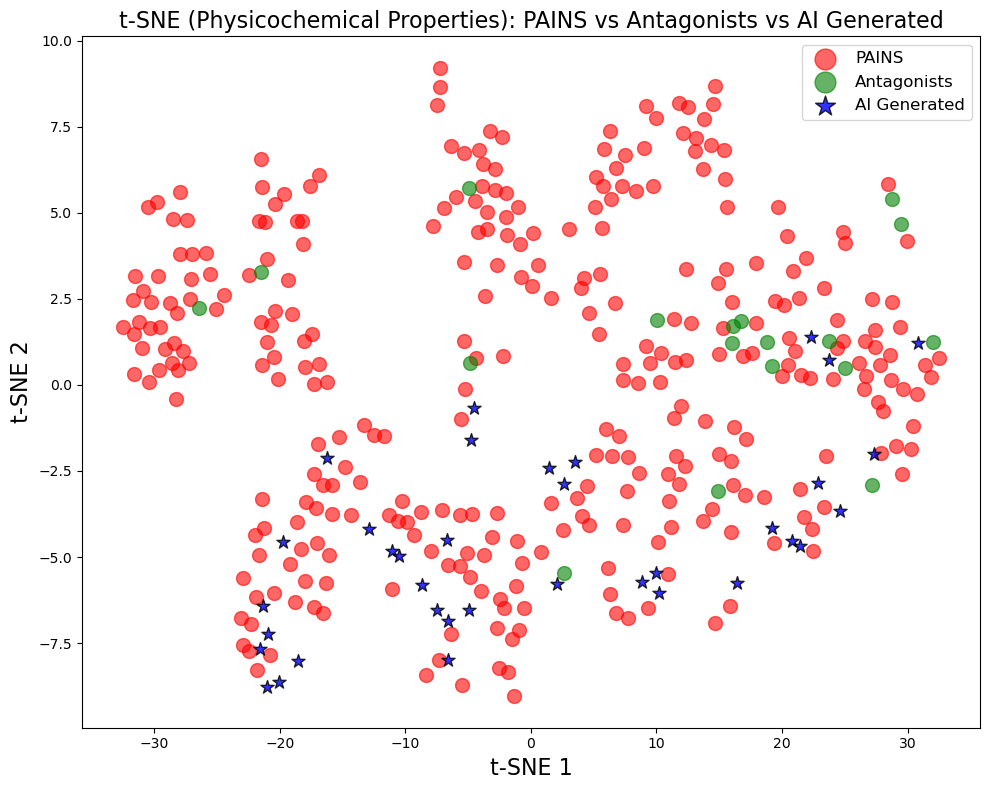

In [10]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Read known data (antagonists + PAINS)
df_known = pd.read_csv("data/2Z65_with_properties_2Z65binding.txt")
df_known['Source'] = 'Known'

# Read AI generated molecules
df_gen = pd.read_csv("results/GenMolMF/2Z65/gpt-4o/241025_1259/all.csv")
df_gen['Source'] = 'AI_Generated'

# Combine datasets
df_combined = pd.concat([df_known, df_gen], ignore_index=True)

# Select physicochemical properties
features = ['MolWt', 'LogP', 'QED', 'SAS', 'TPSA', 'H_Acceptors', 'H_Donors', 'Rotatable_Bonds', 'Affinity', 'CNNaffinity']
X = df_combined[features].values

# t-SNE on physicochemical properties
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X)-1))
coords = tsne.fit_transform(X)

# Split coordinates back
n_known = len(df_known)
coords_known = coords[:n_known]
coords_gen = coords[n_known:]

# Plot
plt.figure(figsize=(10, 8))

# Plot PAINS (label 0) in red
mask_pains = df_known['Label'] == 0
plt.scatter(coords_known[mask_pains, 0], coords_known[mask_pains, 1], 
            label='PAINS', s=100, alpha=0.6, color='red')

# Plot Antagonists (label 1) in green
mask_antagonists = df_known['Label'] == 1
plt.scatter(coords_known[mask_antagonists, 0], coords_known[mask_antagonists, 1], 
            label='Antagonists', s=100, alpha=0.6, color='green')

# Plot AI generated molecules in blue
plt.scatter(coords_gen[:, 0], coords_gen[:, 1], 
            label='AI Generated', s=100, alpha=0.8, marker='*', color='blue', edgecolors='black', linewidths=1)

plt.xlabel('t-SNE 1', fontsize=16)
plt.ylabel('t-SNE 2', fontsize=16)
plt.title('t-SNE (Physicochemical Properties): PAINS vs Antagonists vs AI Generated', fontsize=16)
plt.legend(fontsize=12, markerscale=1.5)
plt.tight_layout()
plt.savefig('tsne_physicochemical_with_generated.png', dpi=300, bbox_inches='tight')
plt.show()